In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#linear regresssion from scratch using pandas matplot and numpy

In [2]:
#loadind the dataset and data pre processing 
df=pd.read_csv(r"C:\Users\Samaira Singh\Downloads\bootcamp\ml\HousingData.csv")
column_means = df.mean(numeric_only=True)
df = df.fillna(column_means)
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B      LSTAT  MEDV  
0  396.90   4.980000  24.0  
1  396.90   9.140000  21.6  
2  392.83   4.030000  34.7  
3  394.63   2.940000  33.4  
4  396.90  12.715432  36.2  


In [3]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [4]:
#extracting data
#dropping the target column to prevent data leakage and overfit
y_train=df["MEDV"].values
X_train=df.drop(columns=["MEDV"]).values
print(X_train[:5]) #prints values  
print(y_train[:5])

[[6.32000000e-03 1.80000000e+01 2.31000000e+00 0.00000000e+00
  5.38000000e-01 6.57500000e+00 6.52000000e+01 4.09000000e+00
  1.00000000e+00 2.96000000e+02 1.53000000e+01 3.96900000e+02
  4.98000000e+00]
 [2.73100000e-02 0.00000000e+00 7.07000000e+00 0.00000000e+00
  4.69000000e-01 6.42100000e+00 7.89000000e+01 4.96710000e+00
  2.00000000e+00 2.42000000e+02 1.78000000e+01 3.96900000e+02
  9.14000000e+00]
 [2.72900000e-02 0.00000000e+00 7.07000000e+00 0.00000000e+00
  4.69000000e-01 7.18500000e+00 6.11000000e+01 4.96710000e+00
  2.00000000e+00 2.42000000e+02 1.78000000e+01 3.92830000e+02
  4.03000000e+00]
 [3.23700000e-02 0.00000000e+00 2.18000000e+00 0.00000000e+00
  4.58000000e-01 6.99800000e+00 4.58000000e+01 6.06220000e+00
  3.00000000e+00 2.22000000e+02 1.87000000e+01 3.94630000e+02
  2.94000000e+00]
 [6.90500000e-02 0.00000000e+00 2.18000000e+00 0.00000000e+00
  4.58000000e-01 7.14700000e+00 5.42000000e+01 6.06220000e+00
  3.00000000e+00 2.22000000e+02 1.87000000e+01 3.96900000e+0

In [5]:
#normalisation
#z score normalisation 
#random seed used so that the output is always same 
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
X_train_norm = (X_train - mu) / sigma
m, n = X_train_norm.shape
np.random.seed(1)
w = np.random.rand(n)
b = 0.0

In [6]:
#cost function
def compute_cost(X,y,w,b):
 m = X.shape[0]
 f_wb = X @ w + b
    
    # Calculate squared error
 cost = (f_wb - y)**2
    
    # Return the mean cost (scaled by 1/2m for cleaner gradient)
 total_cost = np.sum(cost) / (2 * m)
 return total_cost

In [7]:
def compute_gradient(X,y,w,b):
    m = X.shape[0]
    f_wb = X @ w + b    # Predictions: X * w + b
    err = f_wb - y      # Prediction error: (predicted - actual)

    # Vectorized gradient for all weights (dw)
    dw = (X.T @ err) / m

    # Gradient for bias (db)
    db = np.sum(err) / m

    return dw, db


In [8]:
#gradient descent function
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):

    w = w_in
    b = b_in
    J_history = []  # To store cost history 

    for i in range(num_iters):
        # Calculate the gradient 
        dw, db = gradient_function(X, y, w, b)

        # Update rule: Simultaneously update w and b
        w = w - alpha * dw
        b = b - alpha * db

        # Record and print the cost
        cost = cost_function(X, y, w, b)
        J_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i:4d}: Cost {cost:.2f}")

    return w, b, J_history

In [10]:
#applying gradient descent
iterations = 3000

alpha = 0.01  # Learning rate
#smaller learning rate makes the model slow requiring multiple iterations and larger learning rate might cause overshoot and never reach minimum

# Run the algorithm using your normalized data and defined parameters
w_final, b_final, J_hist = gradient_descent(X_train_norm, y_train, w,b, alpha, iterations, compute_cost, compute_gradient)

print("\n--- Manual Gradient Descent Training Complete ---")
print(f"Optimal weights (w): {w_final}")
print(f"Optimal bias (b): {b_final:.2f}")



Iteration    0: Cost 292.67
Iteration  100: Cost 47.22
Iteration  200: Cost 16.82
Iteration  300: Cost 12.58
Iteration  400: Cost 11.88
Iteration  500: Cost 11.69
Iteration  600: Cost 11.60
Iteration  700: Cost 11.54
Iteration  800: Cost 11.50
Iteration  900: Cost 11.47
Iteration 1000: Cost 11.44
Iteration 1100: Cost 11.42
Iteration 1200: Cost 11.41
Iteration 1300: Cost 11.40
Iteration 1400: Cost 11.39
Iteration 1500: Cost 11.38
Iteration 1600: Cost 11.37
Iteration 1700: Cost 11.37
Iteration 1800: Cost 11.36
Iteration 1900: Cost 11.36
Iteration 2000: Cost 11.36
Iteration 2100: Cost 11.35
Iteration 2200: Cost 11.35
Iteration 2300: Cost 11.35
Iteration 2400: Cost 11.35
Iteration 2500: Cost 11.35
Iteration 2600: Cost 11.35
Iteration 2700: Cost 11.34
Iteration 2800: Cost 11.34
Iteration 2900: Cost 11.34

--- Manual Gradient Descent Training Complete ---
Optimal weights (w): [-0.92234393  0.89402928 -0.35272454  0.77633222 -1.91790904  2.90301157
 -0.30629324 -3.13558436  2.08073889 -1.4950

In [11]:
def predict_manual(X, w, b):
    return X @ w + b

y_pred_manual = predict_manual(X_train_norm[:5], w_final, b_final)

print("--- Model Performance on First 5 Samples ---")
print(f"Actual Prices (y_train[:5]): \t{y_train[:5]}")
print(f"Predicted Prices: \t\t{y_pred_manual}")

--- Model Performance on First 5 Samples ---
Actual Prices (y_train[:5]): 	[24.  21.6 34.7 33.4 36.2]
Predicted Prices: 		[30.34258094 24.90928718 30.60469407 28.91834105 24.91513368]


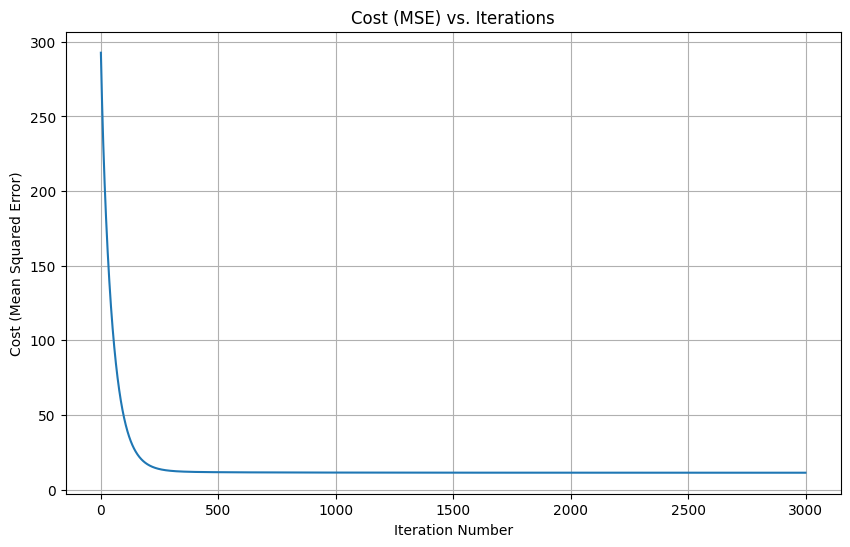


Cost history plot displayed.


In [12]:
#plot cost history
plt.figure(figsize=(10, 6))
plt.plot(range(iterations), J_hist)
plt.title("Cost (MSE) vs. Iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Cost (Mean Squared Error)")
plt.grid(True)
plt.show()

print("\nCost history plot displayed.")
#as number of iterations increase the cost function converges

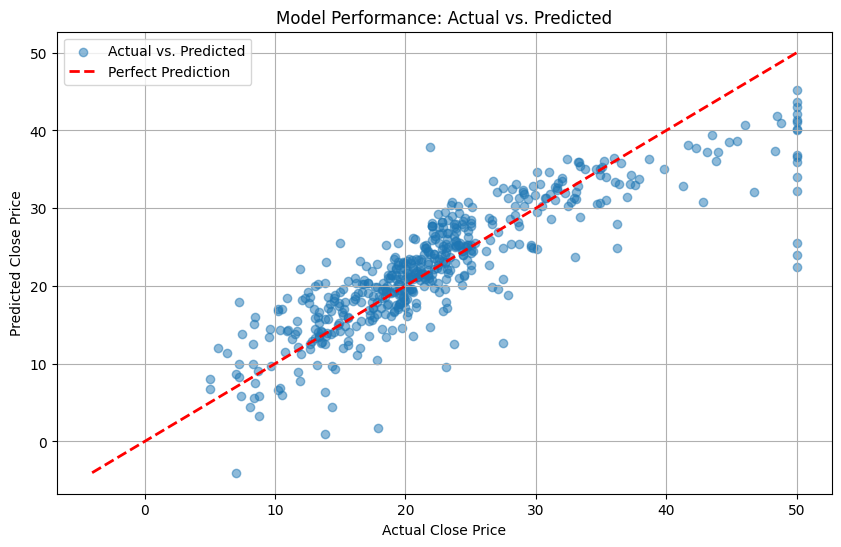

In [13]:

#final predictions 
y_pred_full = predict_manual(X_train_norm, w_final, b_final)
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_full, alpha=0.5, label='Actual vs. Predicted')
#y=x perfect line
min_val = min(np.min(y_train), np.min(y_pred_full))
max_val = max(np.max(y_train), np.max(y_pred_full))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Model Performance: Actual vs. Predicted')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.legend()
plt.grid(True)
plt.show()

